# Netflix Case Study

# step-1(a):-  problem statement :

# Analyze the dataset & provide the data driven recommendations/insights on the basis of type of shows, Netflix should produce to grow the business globally

# importing necessary libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Reading the dataset

In [10]:
df = pd.read_csv('/Users/gyanprakash/Documents/Data Science/netflix.csv')

# Understanding Data/ Data Exploration

In [11]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [13]:
# viewing dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [15]:
df.shape    # dataset contains 8807 rows & 12 columns 

(8807, 12)

In [17]:
# Displaying data types of each column.
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

# Step-1(b) Analysing basic metrics

In [19]:
# Basic Metrics:- Unique Values: 

# Unique value counts for key columns in the dataset
print("Types:", df['type'].nunique())
print("Titles:", df['title'].nunique())
print("Directors:", df['director'].nunique())
print("Countries:", df['country'].nunique())
print("Years (of release):", df['release_year'].nunique())
print("Ratings:", df['rating'].nunique())
print("Genres (Listed In):", df['listed_in'].nunique())



Types: 2
Titles: 8807
Directors: 4528
Countries: 748
Years (of release): 74
Ratings: 17
Genres (Listed In): 514


# Step-2  Observations on the shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), missing value detection, statistical summary

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


#  Summary statistics for numerical columns

In [23]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1714,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,110,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


# Step-2(a) 

# Data Types:
Most columns are of object Dtype, which means they are string-based:

Type, rating, listed_in
We need to convert them to category to improve efficiency.

Type → 2 unique values (Movie, TV Show)

Ratings → 17 unique values (TV-MA, PG-13, etc.)

# step-2(b)

In [27]:
df['type'] = df['type'].astype('category')
df['rating'] = df['rating'].astype('category')


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   show_id       8807 non-null   object  
 1   type          8807 non-null   category
 2   title         8807 non-null   object  
 3   director      6173 non-null   object  
 4   cast          7982 non-null   object  
 5   country       7976 non-null   object  
 6   date_added    8797 non-null   object  
 7   release_year  8807 non-null   int64   
 8   rating        8803 non-null   category
 9   duration      8804 non-null   object  
 10  listed_in     8807 non-null   object  
 11  description   8807 non-null   object  
dtypes: category(2), int64(1), object(9)
memory usage: 706.2+ KB


# Step-2(c) Missing Values detection:

In [31]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Missing Values:

director :-	2634 ,
cast :-	825 ,
country:- 831 ,
date_added:- 10 ,
rating:- 4 ,
duration:- 3 
country, rating, date_added, and duration. We have to handle these missing values

# Step-2(d) Statistical Sumaary

In [33]:
# # exploring summary statistics
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# Statistical Summary (for release_year):
Metric	Value
Min Year:-1925,
Max Year:-2021,
Mean Year:- ~2014(approx),
25% Quartile:- 2013,
75% Quartile:- 2019

Most content available on Netflix is recent — post-2010 content dominates.



# Step-3 Non-Graphical Analysis: Value counts and unique attributes
# Step-3(a)

In [35]:


# Value counts for type (Movie vs TV Show)
print("Type Counts:\n", df['type'].value_counts(), "\n")

# Value counts for rating (TV-MA, PG, etc.)
print("Rating Counts:\n", df['rating'].value_counts(), "\n")

# Top 10 most common countries
print("Top Countries:\n", df['country'].value_counts().head(10), "\n")

# Top 10 directors with most titles
print("Top Directors:\n", df['director'].value_counts().head(10), "\n")

# Top 10 genre combinations
print("Top Genres:\n", df['listed_in'].value_counts().head(10), "\n")

# Number of titles released each year (sorted by year)
print("Titles per Year:\n", df['release_year'].value_counts().sort_index().tail(10))


Type Counts:
 type
Movie      6131
TV Show    2676
Name: count, dtype: int64 

Rating Counts:
 rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
UR             3
NC-17          3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64 

Top Countries:
 country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64 

Top Directors:
 director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielb

# Insights:

Netflix has more movies than TV shows( ~ twice)

Netflix shoukd focus more on TV Shows, which tends to gather users over a long period of time.


Most of the content is targeted at mature audiences (TV-MA, TV-14, R).

Family-friendly or kid content (like TV-Y, TV-Y7, PG) is comparatively less.

Also some outliers like 74 min and 84 min in the rating column likely belong to duration 

Most common rating: TV-MA (3,207 times)

Most common genre: Dramas, International Movies

Most frequent country: United States (2,818 times)

Most famous directors 
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18

Release year range: 1925 to 2021

Majority of releases after: 2013





# Step-3(b)
# finding the no. of unique attributes (values) in each column

In [37]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1714
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

In [39]:
# To see all unique values in the 'rating' column
df['rating'].unique()


['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', ..., '66 min', 'NR', NaN, 'TV-Y7-FV', 'UR']
Length: 18
Categories (17, object): ['66 min', '74 min', '84 min', 'G', ..., 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR']

In [41]:
df['rating'].nunique()


17

In [43]:
unique_actors = df['cast'].dropna().apply(lambda x: [i.strip() for i in x.split(',')]).explode().nunique()
print("Unique Actors:", unique_actors)


Unique Actors: 36440


In [107]:
# Unnesting 'Actor' column
df_unnested_actors = df.explode('cast')

# Unnesting 'Director' column
df_unnested_directors = df.explode('director')

# Unnesting 'Country' column
df_unnested_countries = df.explode('country')


# Visualization

# Visual Analysis - Univariate, Bivariate after pre-processing of the data¶
# 4(a) For continuous variable(s): Distplot, countplot, histogram for univariate analysis 
# Percentage of Titles

# Movies vs TV shows

Text(0.5, 1.0, 'count vs type of shows')

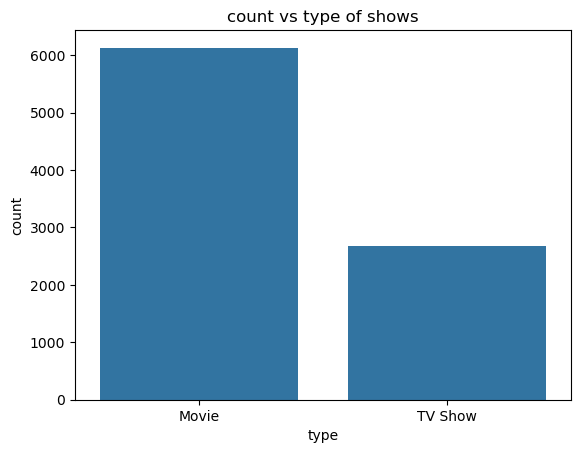

In [16]:
# count vs type of shows

df.type.value_counts()
sns.countplot(x = 'type', data = df)
plt.title('count vs type of shows')

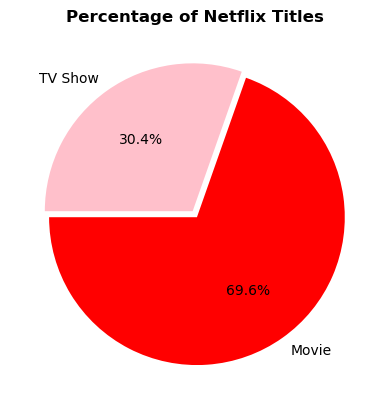

In [14]:
plt.title("Percentage of Netflix Titles", fontweight="bold")
g=plt.pie(df.type.value_counts(),explode=(0.025,0.025),
labels=df.type.value_counts().index, colors=['red','pink'],autopct='%1.1f%%',startangle=180)


In [12]:
print(df['type'].unique())
print(df['type'].value_counts())


['Movie' 'TV Show']
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


Text(0.5, 1.0, 'country wise content on netflix')

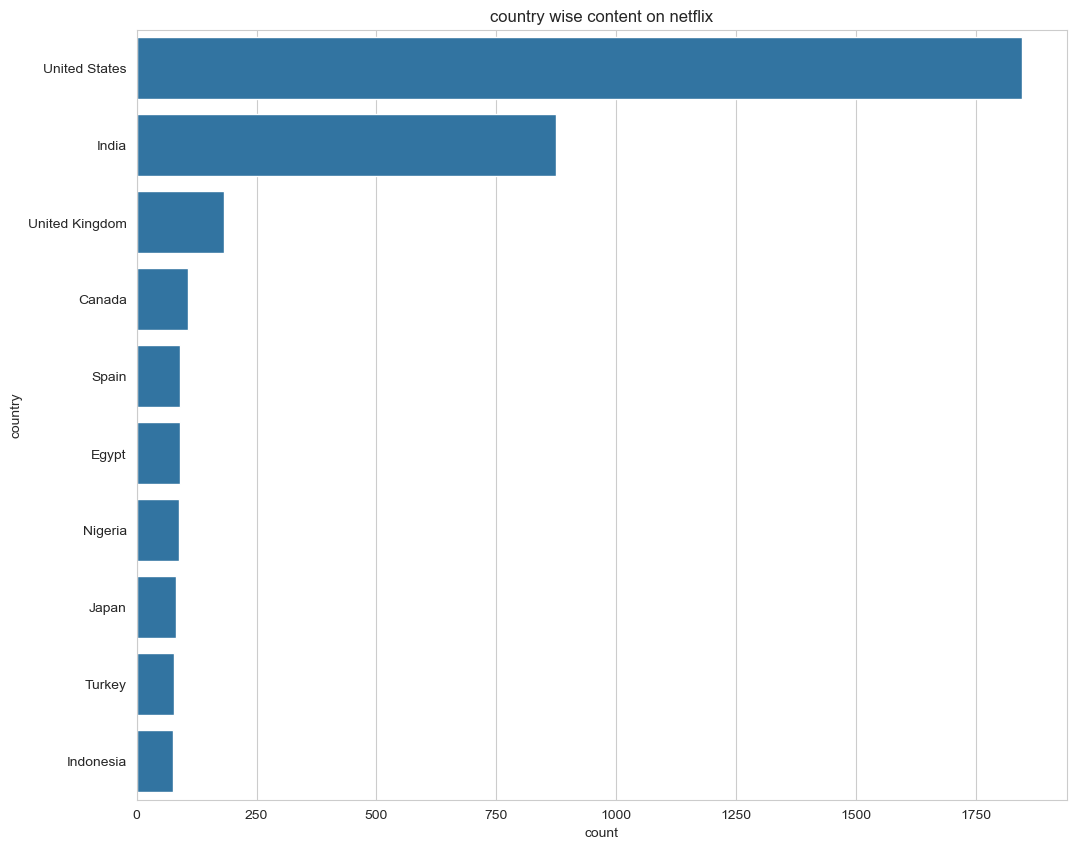

In [196]:
plt.figure(figsize=(12,10))
sns.countplot(y='country', order = df['country'].value_counts().index[:10],data = df)
plt.title('country wise content on netflix')
              

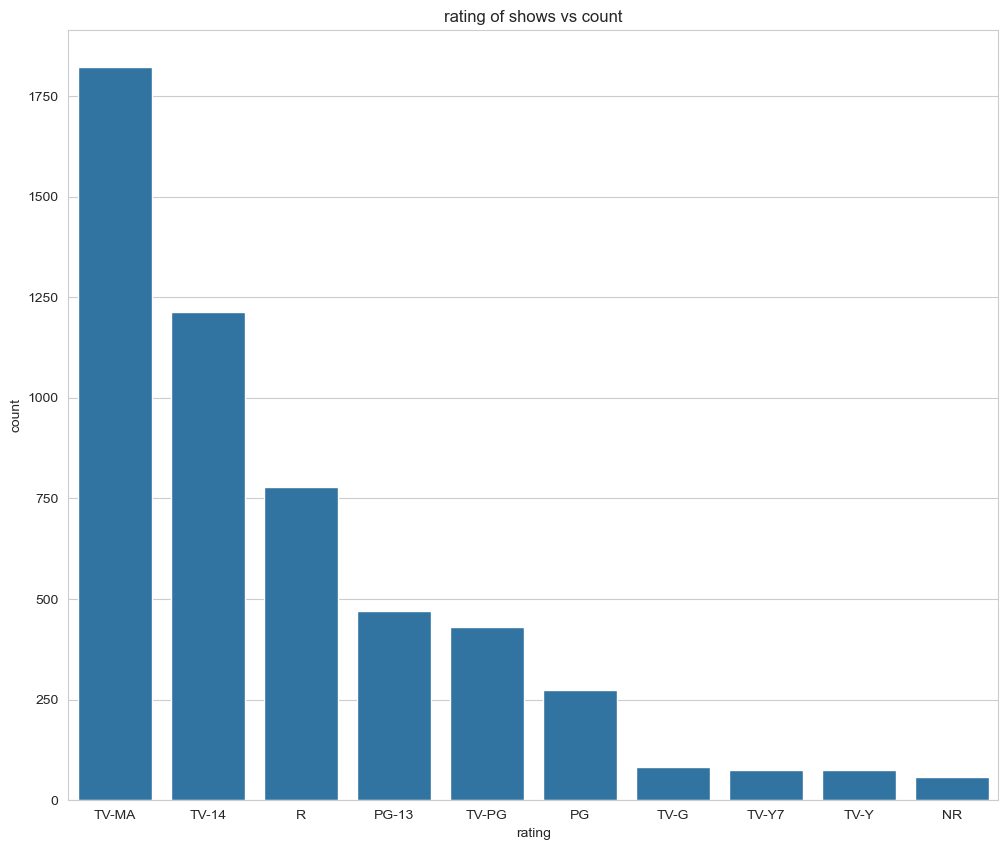

In [198]:
df.rating.value_counts()
plt.figure(figsize=(12,10))
sns.countplot(x= 'rating',order = df['rating'].value_counts().index[0:10],data = df)
plt.title('rating of shows vs count')
plt.show()


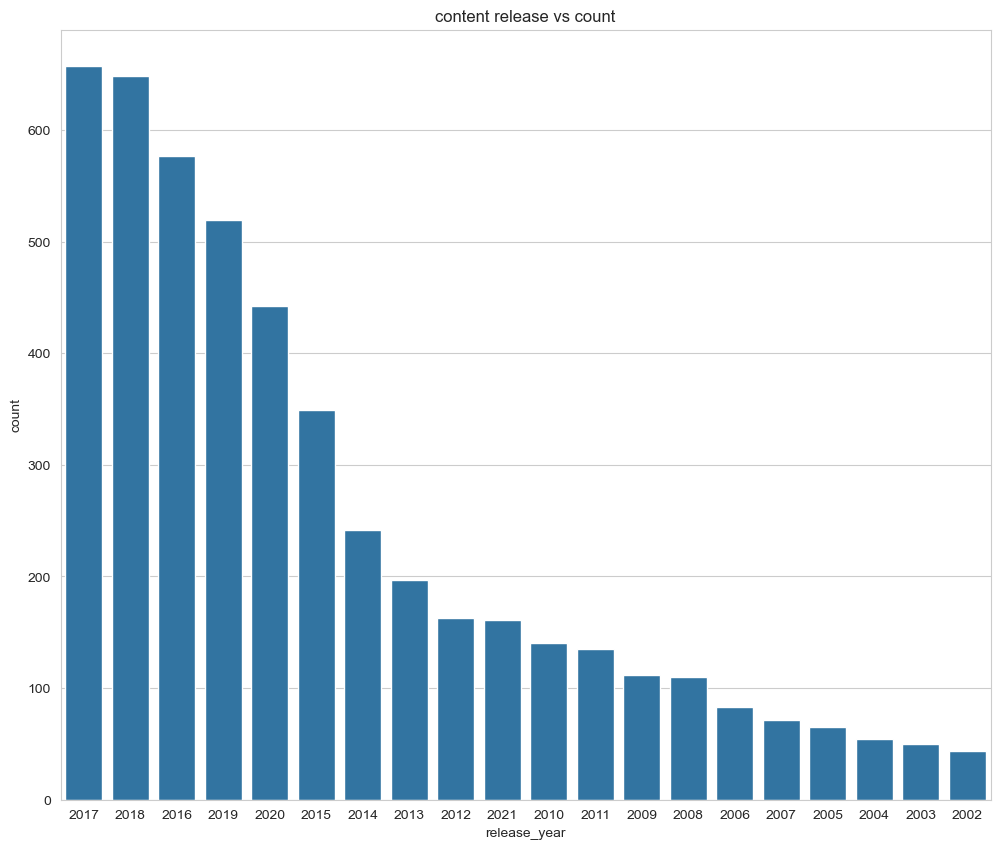

In [200]:
df.release_year.value_counts()[:20]
plt.figure(figsize =(12,10))
sns.countplot( x= 'release_year',order = df['release_year'].value_counts().index[:20], data= df)
plt.title('content release vs count')
plt.show()

# Dist plot of release year

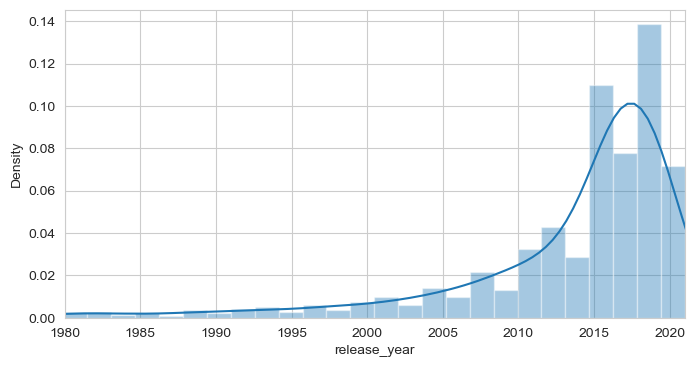

In [212]:

plt.figure(figsize=(8,4))
sns.distplot(df['release_year']) 
plt.xlim(1980,2021)
plt.show()

# Year-wise distributions

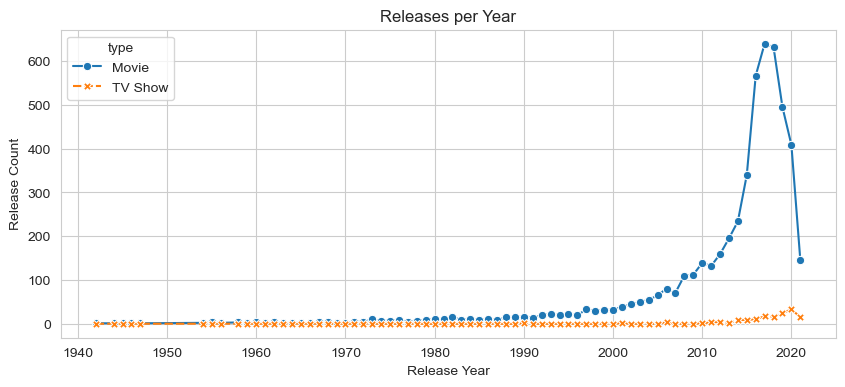

In [210]:
import matplotlib.pyplot as plt
import seaborn as sns

# First, calculate the count of releases per year
release_year_counts = df.groupby(['release_year', 'type']).size().reset_index(name='release_year_count')

# Now, plot the lineplot 
plt.figure(figsize=(10, 4))
sns.set_style("whitegrid")

# Plotting the lineplot with the aggregated data
gfg = sns.lineplot(x="release_year", y="release_year_count", hue="type", style="type", markers=True, data=release_year_counts)

# Add labels to the axis and title to the plot
gfg.set(xlabel="Release Year", ylabel="Release Count", title="Releases per Year")

# Show the plot
plt.show()


In [147]:
# Count the number of occurrences for each director and sort them in descending order
top_directors = df['director'].value_counts().head(10)

# Display the top 10 directors
print(top_directors)


director
Raúl Campos, Jan Suter    18
Marcus Raboy              15
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Don Michael Paul          10
David Dhawan               9
Name: count, dtype: int64


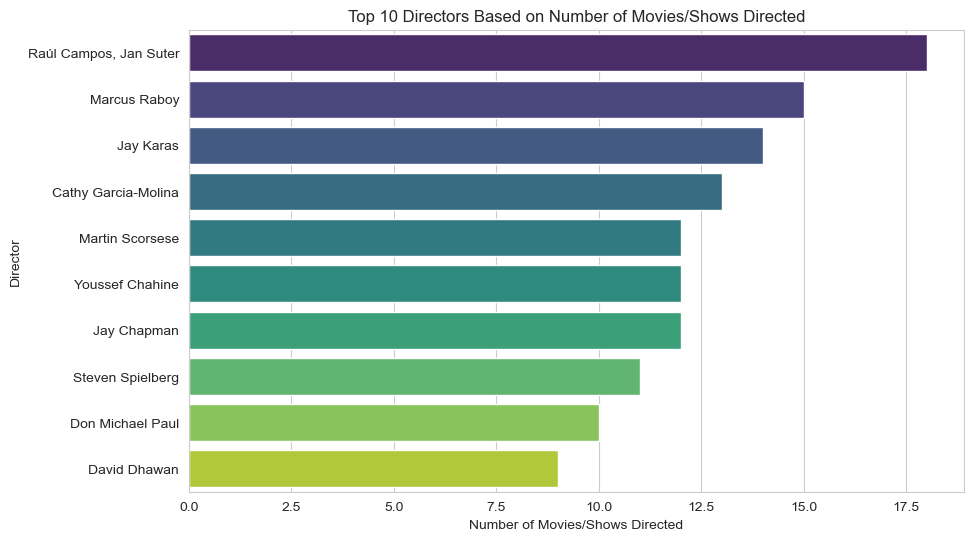

In [216]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis')
plt.xlabel('Number of Movies/Shows Directed')
plt.ylabel('Director')
plt.title('Top 10 Directors Based on Number of Movies/Shows Directed')
plt.show()



In [155]:
# Find top 10 genres by splitting the 'listed_in' column
top_genres = df['listed_in'].str.split(',').explode().str.strip().value_counts().nlargest(10)

# Display the top 10 genres
print(top_genres)


listed_in
International Movies        2369
Dramas                      2293
Comedies                    1553
Action & Adventure           806
Independent Movies           740
Romantic Movies              579
Thrillers                    547
Children & Family Movies     503
Documentaries                391
Horror Movies                336
Name: count, dtype: int64


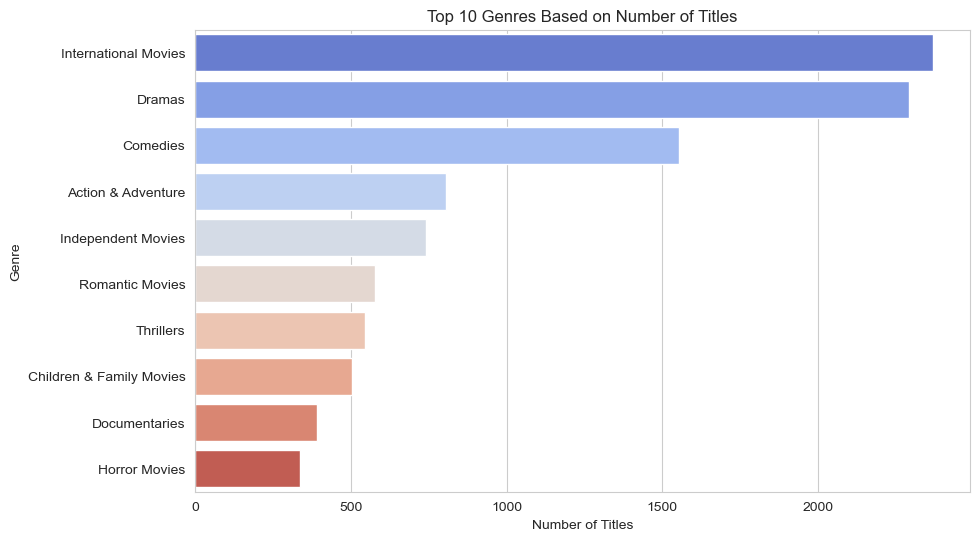

In [220]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='coolwarm')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.title('Top 10 Genres Based on Number of Titles')
plt.show()


In [167]:
comparison = df['type'].value_counts()


In [173]:
movies_df = df[df['type'] == 'Movie']
movie_counts = movies_df.groupby('country')['show_id'].nunique().reset_index()
movie_counts = movie_counts[movie_counts.country!="Unavailable"]
top_10_movie_countries = movie_counts.sort_values(by='show_id', ascending=False).head(10)
top_10_movie_countries.rename(columns={'show_id':'Movies_count'}, inplace=True)
top_10_movie_countries

,country,Movies_count
481,United States,1819
192,India,868
403,United Kingdom,164
43,Canada,104
110,Egypt,90
349,Spain,84
287,Nigeria,84
212,Indonesia,76
391,Turkey,74
249,Japan,73


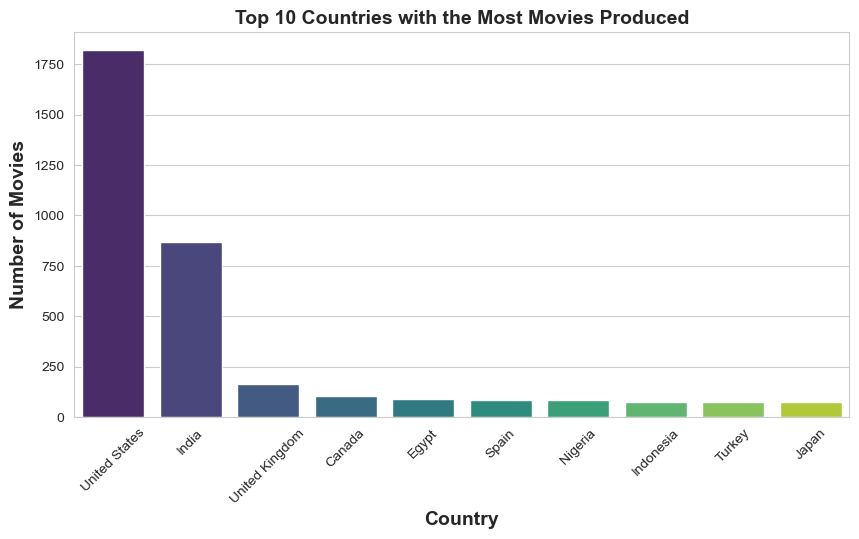

In [222]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_movie_countries, x='country', y='Movies_count', palette='viridis')
plt.xlabel('Country', fontsize=14, fontweight='bold')
plt.ylabel('Number of Movies', fontsize=14, fontweight='bold')
plt.title('Top 10 Countries with the Most Movies Produced', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()


# 4(b)For categorical variable(s): Boxplot

(2000.0, 2020.0)

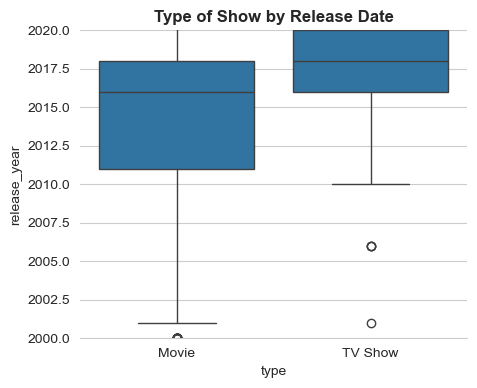

In [179]:
plt.figure(figsize=(5,4))
sns.boxplot(x='type', y='release_year', data=df)
sns.despine(left=True)
plt.title('Type of Show by Release Date', fontweight='bold')
plt.ylim(2000,2020)

In [9]:
# The boxplot shows the distribution of release years for Movies and TV Shows.
# We can observe that both types of content have mostly been released after 2000,
# This suggests an increasing trend in TV Show production over time.


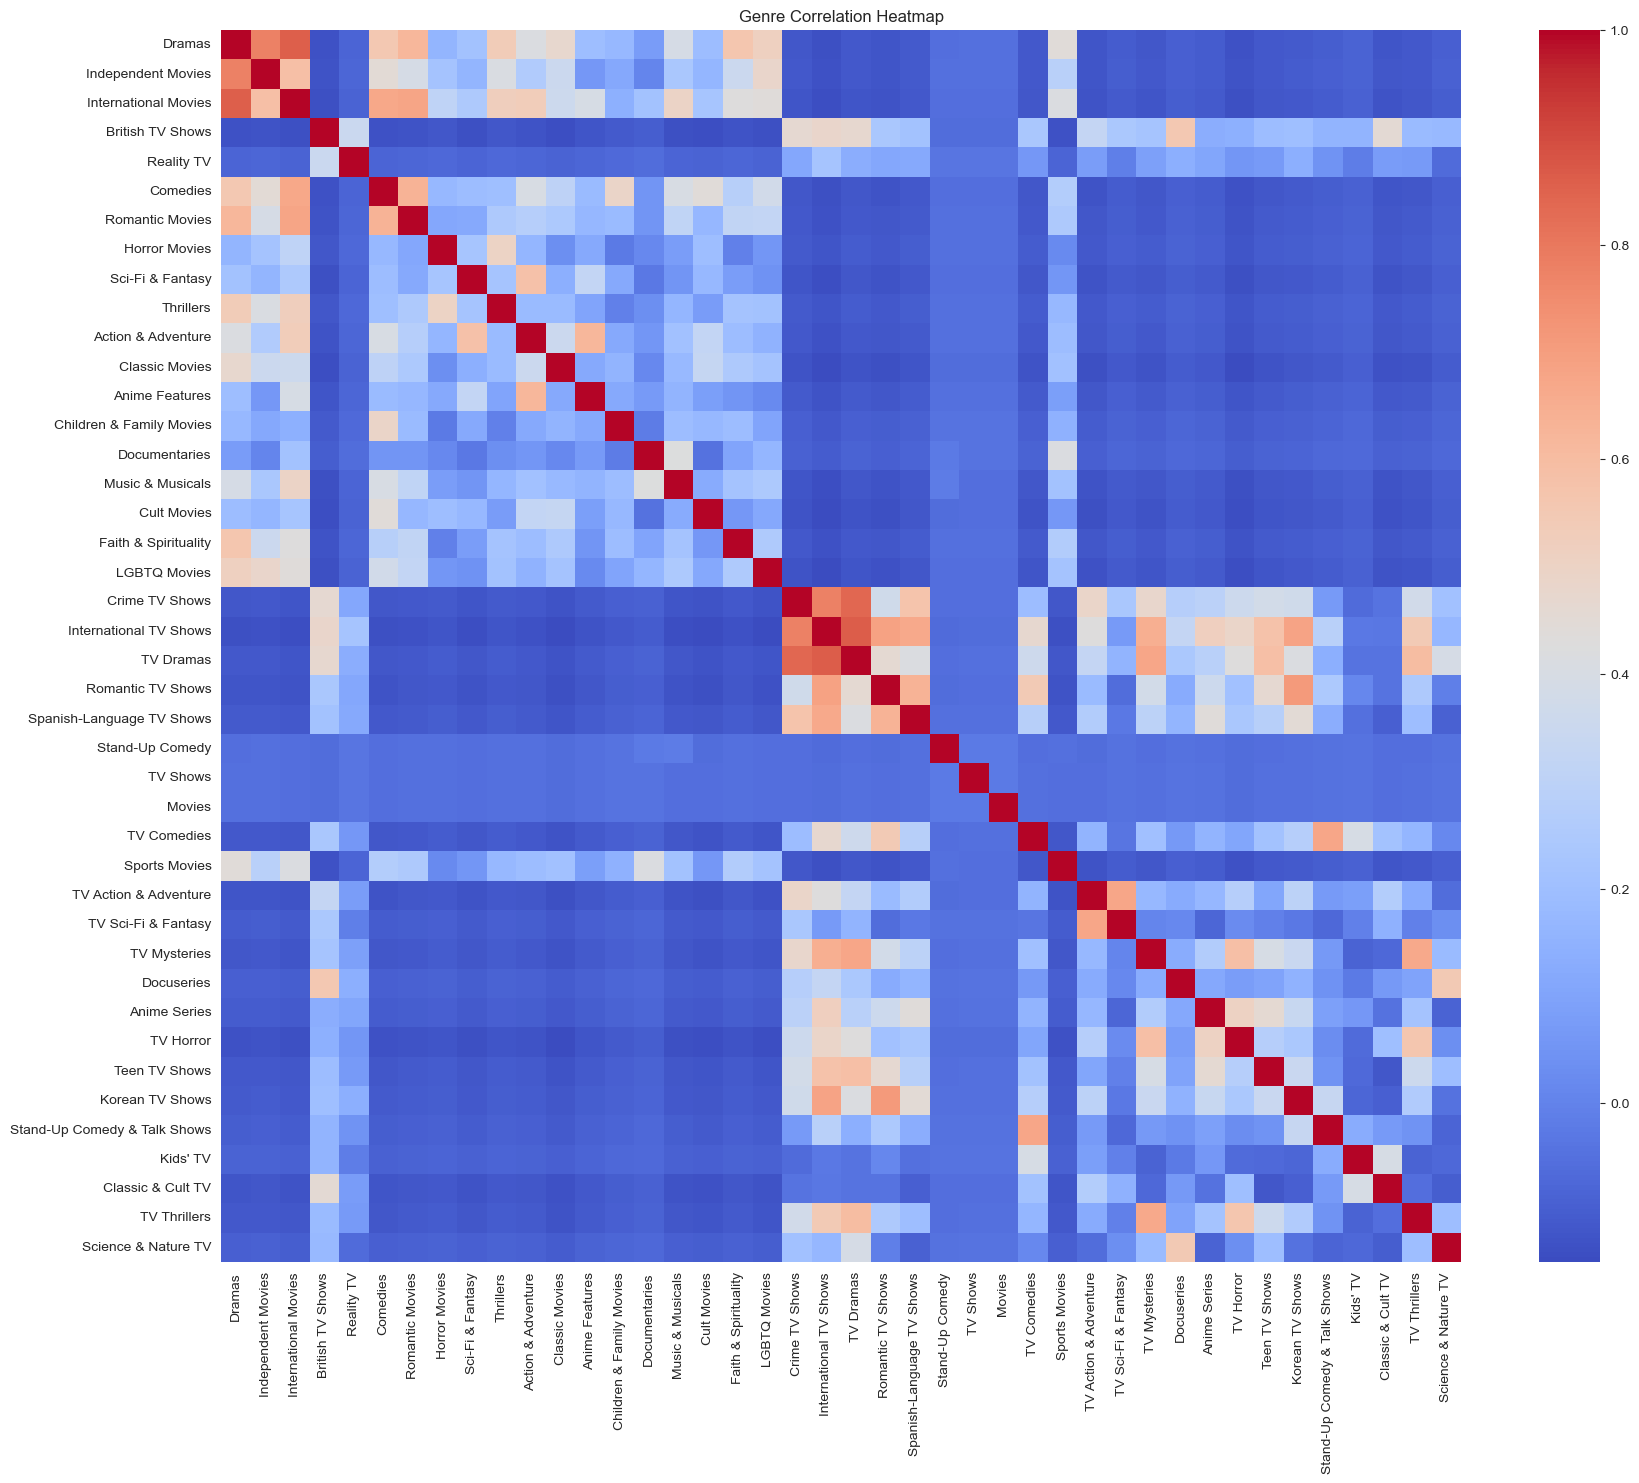

In [185]:
genres = df['listed_in'].str.split(', ', expand=True).stack().unique()
genre_data = pd.DataFrame(index=genres, columns=genres, dtype=float)

# Fill the genre data DataFrame with zeros
genre_data.fillna(0, inplace=True)

# Iterate over each row in the original DataFrame and update the genre data DataFrame
for _, row in df.iterrows():
    listed_in = row['listed_in'].split(', ')
    for genre1 in listed_in:
        for genre2 in listed_in:
            genre_data.at[genre1, genre2] += 1

# Create a correlation matrix using the genre data
correlation_matrix = genre_data.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')

plt.title('Genre Correlation Heatmap')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# The heatmap demonstrates the correlation between different genres. By analyzing the heatmap, we can identify strong positive correlations between specific genres, such as TV Dramas and International TV Shows, Romantic TV Shows, and International TV Shows.

<function matplotlib.pyplot.show(close=None, block=None)>

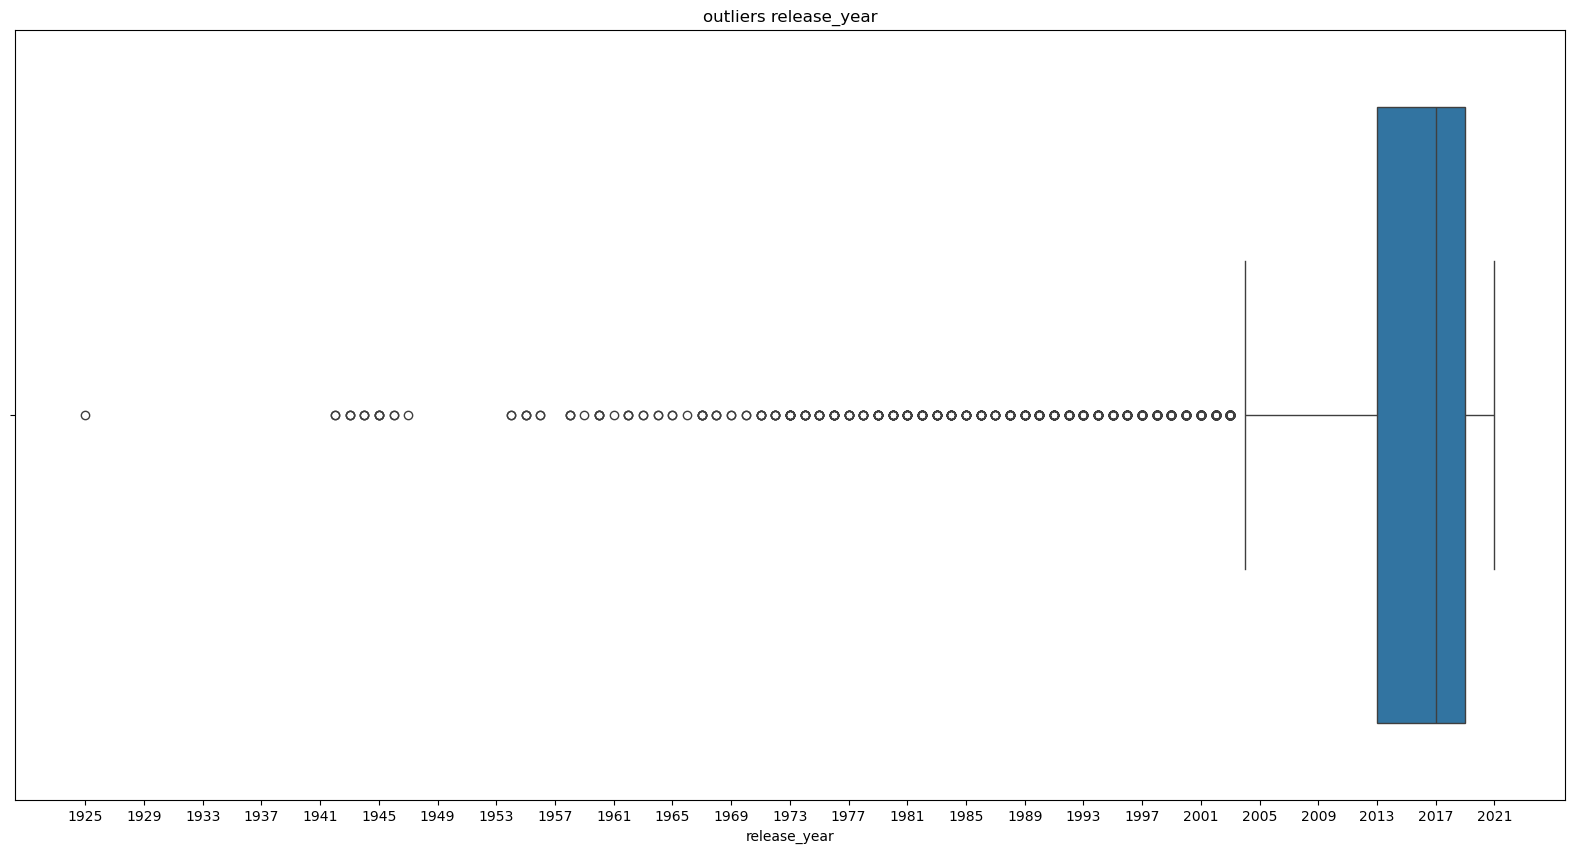

In [27]:
plt.figure(figsize=(20,10))
sns.boxplot(data = df, x= 'release_year')
plt.xticks(range(1925,2022,4))
plt.title('outliers release_year')
plt.show

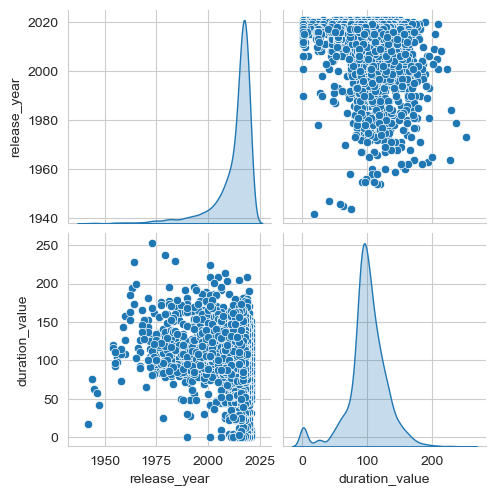

In [235]:

# 5. missing values detection


p = sns.pairplot(df, kind='scatter', diag_kind='kde')
plt.show()

In [233]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
duration_value    0
duration_unit     0
dtype: int64

# 6.Insights


In [20]:
# Insights:

Netflix prdouced more movies than TV shows( ~ twice)

Netflix shoukd focus more on TV Shows, which tends to gather users over a long period of time.

Most of the content is targeted at mature audiences (TV-MA, TV-14, R).

Family-friendly or kid content (like TV-Y, TV-Y7, PG) is comparatively less.

Also some outliers like 74 min and 84 min in the rating column likely belong to duration 

Most common rating: TV-MA (3,207 times)

Most common genre: Dramas, International Movies

Most frequent country: United States (2,818 times)

Most prolific director:Raul campus & jan suter (18 titles)

Release year range: 1925 to 2021

Majority of releases after: 2013 


SyntaxError: invalid syntax (199396666.py, line 3)

# 7. 
Most content is from the USA

Most movies are 90-120 minutes

TV shows mostly have 1-2 seasons

Release count trends between 2018–2020
The USA dominates (at top) in content & number of movies.

Most movies are ~100 mins(b/w 90-120 mins).

Genres like international content & drama are top performing .



# 8. Recommendations

Most famous directors ( Rajiv Chilaka 19 Raúl Campos, Jan Suter 18 ) more contents from these directors should be added to the platform 

most of the audience are MA ( mature Adults) , these contents should be increased liked by MA , TV-14, R 

Expand partnerships with countries like India, UK, Spain, egypt etc 

Produce short TV series with 1–2 seasons to gathher audience on their platform

Invest in top-performing genres like drama, international, thrillers


In [2]:
pip install pandoc

  Preparing metadata (setup.py) ... done
  Created wheel for pandoc: filename=pandoc-2.4-py3-none-any.whl size=34792 sha256=7fe1d97cebf247a223c5f35ac2bf38e8e4e99c2b17cc9d4f08243894a0dfe997
  Stored in directory: /Users/gyanprakash/Library/Caches/pip/wheels/9c/2f/9f/b1aac8c3e74b4ee327dc8c6eac5128996f9eadf586e2c0ba67
Successfully built pandoc
Note: you may need to restart the kernel to use updated packages.
